In [1]:
import pandas as pd
print(pd.__version__)

2.2.3


In [2]:
# Assuming you have a CSV file to read the initial data from
csv_file_path = 'dataset/price_emas_fix.csv'

# Read the CSV file into a DataFrame
price_emas_fix_df = pd.read_csv(csv_file_path)

# Use the exact column name
exact_column_name = price_emas_fix_df.columns[0]

# Extract the price data from the exact column name
price_emas_fix_df['price'] = price_emas_fix_df[exact_column_name].str.extract(r'(\d+)]')

# Extract the time data from the exact column name
price_emas_fix_df['time'] = price_emas_fix_df[exact_column_name].str.extract(r'\[(\d+)')

# Drop the original column
price_emas_fix_df.drop(columns=[exact_column_name], inplace=True)

# Move the 'price' column up by one row
price_emas_fix_df['price'] = price_emas_fix_df['price'].shift(-1)

# Remove rows with missing values in 'price' or 'time' columns
price_emas_fix_df.dropna(subset=['price', 'time'], inplace=True)

# Display the first few rows of the updated DataFrame
price_emas_fix_df.head()


,price,time
0,408000,1262596020000
2,410000,1262683680000
4,410000,1262761260000
6,412000,1262857500000
8,410000,1262943420000


In [3]:
# Convert the 'time' column from Unix timestamp to datetime
price_emas_fix_df['time'] = pd.to_datetime(price_emas_fix_df['time'], unit='ms')

# Extract only the date, month, and year
price_emas_fix_df['date'] = price_emas_fix_df['time'].dt.date
price_emas_fix_df['month'] = price_emas_fix_df['time'].dt.month
price_emas_fix_df['year'] = price_emas_fix_df['time'].dt.year

# Display the first few rows of the updated DataFrame
price_emas_fix_df.head()
price_emas_fix_df.to_csv('dataset/price_emas_fix_final.csv', index=False)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14224\715556365.py:2: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  price_emas_fix_df['time'] = pd.to_datetime(price_emas_fix_df['time'], unit='ms')


# 1 Buka Dataset Final

In [4]:
# Define the file path
csv_file_path_final = 'dataset/price_emas_fix_final.csv'

# Read the CSV file into a DataFrame
price_emas_fix_final_df = pd.read_csv(csv_file_path_final)

# Select only the 'price' and 'date' columns
price_emas_fix_final_df = price_emas_fix_final_df[['price', 'date']]

# Display the first few rows of the DataFrame
price_emas_fix_final_df.head()

,price,date
0,408000,2010-01-04
1,410000,2010-01-05
2,410000,2010-01-06
3,412000,2010-01-07
4,410000,2010-01-08


# Ambil Data Emas Global

In [75]:
import requests

# Define the API URL
api_url = "https://fsapi.gold.org/api/goldprice/v11/chart/main?cache09092024&startDate=2010-02-28&endDate=2025-03-07"

# Send a GET request to the API URL
# Check if the request was successful
response = requests.get(api_url)
if response.status_code == 200:
    # Parse the JSON response
    data = response.json()
    
    # Convert the JSON data to a DataFrame
    gold_price_df = pd.DataFrame(data['chartData']['lbma_am_usd'])
    
    # Define the file path to save the CSV
    json_file_path = 'dataset/lbma.json'
    
    # Save the DataFrame to a CSV file
    gold_price_df.to_csv(json_file_path, index=False)
else:
    print(f"Failed to retrieve data: {response.status_code}")


# Define the file path to save the CSV
csv_file_path_lbma = 'dataset/lbma.csv'

# Save the DataFrame to a CSV file
gold_price_df.to_csv(csv_file_path_lbma, index=False)

In [76]:
# Define the file path
gold_price_csv_file_path = 'dataset/gold_price_data.csv'

# Read the CSV file into a DataFrame
gold_price_csv_df = pd.read_csv(gold_price_csv_file_path)

# Display the first few rows of the DataFrame
gold_price_csv_df.head()

# Rename the columns
gold_price_csv_df.columns = ['time', 'price']

# Display the first few rows of the updated DataFrame
gold_price_csv_df['time'] = pd.to_datetime(gold_price_csv_df['time'], unit='ms')

# Extract only the year, month, and date
gold_price_csv_df['year'] = gold_price_csv_df['time'].dt.year
gold_price_csv_df['month'] = gold_price_csv_df['time'].dt.month
gold_price_csv_df['date'] = gold_price_csv_df['time'].dt.date

# Display the first few rows of the updated DataFrame
gold_price_csv_df.head()

gold_price_csv_df.to_csv('dataset/gold_price_data_fix_final.csv', index=False)
gold_price_csv_df.head()

,time,price,year,month,date
0,1970-01-01,1.13074,1970,1,1970-01-01
1,1970-02-11,1.12335,1970,2,1970-02-11
2,1970-03-24,1.12495,1970,3,1970-03-24
3,1970-05-04,1.14521,1970,5,1970-05-04
4,1970-06-12,1.15582,1970,6,1970-06-12


## Ambil Data Kurs USD ke IDR

In [77]:
# Define the file path
usd_idr_csv_file_path = 'dataset/USD_IDR Historical Data.csv'

# Read the CSV file into a DataFrame
usd_idr_df = pd.read_csv(usd_idr_csv_file_path)

# Display the first few rows of the DataFrame

usd_idr_df = usd_idr_df[['Date', 'Price']]

# Rename the 'Price' column to 'kurs'
usd_idr_df.rename(columns={'Price': 'kurs'}, inplace=True)

# Convert the 'Date' column to datetime format
usd_idr_df['Date'] = pd.to_datetime(usd_idr_df['Date'], format='%m/%d/%Y')

# Change the format to YYYY-MM-DD
usd_idr_df['Date'] = usd_idr_df['Date'].dt.strftime('%Y-%m-%d')

usd_idr_df.head()

,Date,kurs
0,2025-03-07,"16,290.0"
1,2025-03-06,"16,325.0"
2,2025-03-05,"16,310.0"
3,2025-03-04,"16,440.0"
4,2025-03-03,"16,475.0"


In [78]:
# Ensure the 'date' column in gold_price_csv_df is in the same format as 'Date' in usd_idr_df
gold_price_csv_df['date'] = gold_price_csv_df['date'].astype(str)

# Merge the DataFrames on the 'date' and 'Date' columns
merged_df = pd.merge(gold_price_csv_df, usd_idr_df, left_on='date', right_on='Date')

# Rename the 'price' column to 'world_gold'
merged_df.rename(columns={'price': 'world_gold'}, inplace=True)

# Keep only the 'world_gold', 'date', and 'kurs' columns
merged_df = merged_df[['world_gold', 'date', 'kurs']]

# Calculate the gold price in IDR
merged_df['gold_world_idr'] = merged_df['kurs'].str.replace(',', '').astype(float) * merged_df['world_gold']

# Display the first few rows of the merged DataFrame
merged_df.head()

,world_gold,date,kurs,gold_world_idr
0,27.2799,2009-01-07,"10,750.0",293258.9250
1,31.1219,2009-02-17,"11,900.0",370350.6100
2,29.8359,2009-03-30,"11,555.0",344753.8245
3,29.1607,2009-05-08,"10,375.0",302542.2625
4,30.2378,2009-06-18,"10,280.0",310844.5840


In [79]:
# Read the CSV file into a DataFrame
price_antam = pd.read_csv(csv_file_path_final)
# Rename the 'price' column to 'antam'
price_antam.rename(columns={'price': 'antam'}, inplace=True)

# Select only the 'date' and 'antam' columns
price_antam = price_antam[['date', 'antam']]

# Display the first few rows of the DataFrame
price_antam.head()

,date,antam
0,2010-01-04,408000
1,2010-01-05,410000
2,2010-01-06,410000
3,2010-01-07,412000
4,2010-01-08,410000


# Satukan Data

### Perbandingan Harga Emas Antam dan Harga Emas Duniam

In [2]:
pip install sklearn

Defaulting to user installation because normal site-packages is not writeable
  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [3]:
from sklearn.linear_model import LinearRegression
import numpy as np
############################################################################
# Merge the DataFrames on the 'date' column
final_merged_df = pd.merge(price_antam, merged_df, on='date', how='right')

# Display the first few rows of the merged DataFrame
final_merged_df.head()

# Prepare the data for linear regression
# Drop rows where 'antam' is not null
train_data = final_merged_df.dropna(subset=['antam'])

# Use 'gold_world_idr' as the feature and 'antam' as the target
X_train = train_data[['gold_world_idr']]
y_train = train_data['antam']

# Fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict the missing 'antam' values
missing_data = final_merged_df[final_merged_df['antam'].isnull()]
X_missing = missing_data[['gold_world_idr']]
predicted_antam = model.predict(X_missing)

# Fill the missing 'antam' values with the predicted values
final_merged_df.loc[final_merged_df['antam'].isnull(), 'antam'] = predicted_antam
############################################################################

# Extract the year from the 'date' column
final_merged_df['year'] = pd.to_datetime(final_merged_df['date']).dt.year

# Calculate the difference between 'antam' and 'gold_world_idr'
final_merged_df['difference'] = final_merged_df['antam'] - final_merged_df['gold_world_idr']

# Display the first few rows of the updated DataFrame
final_merged_df.head()

ModuleNotFoundError: No module named 'sklearn'

   antam  gold_world_idr
0    NaN     293258.9250
1    NaN     370350.6100
2    NaN     344753.8245
3    NaN     302542.2625
4    NaN     310844.5840


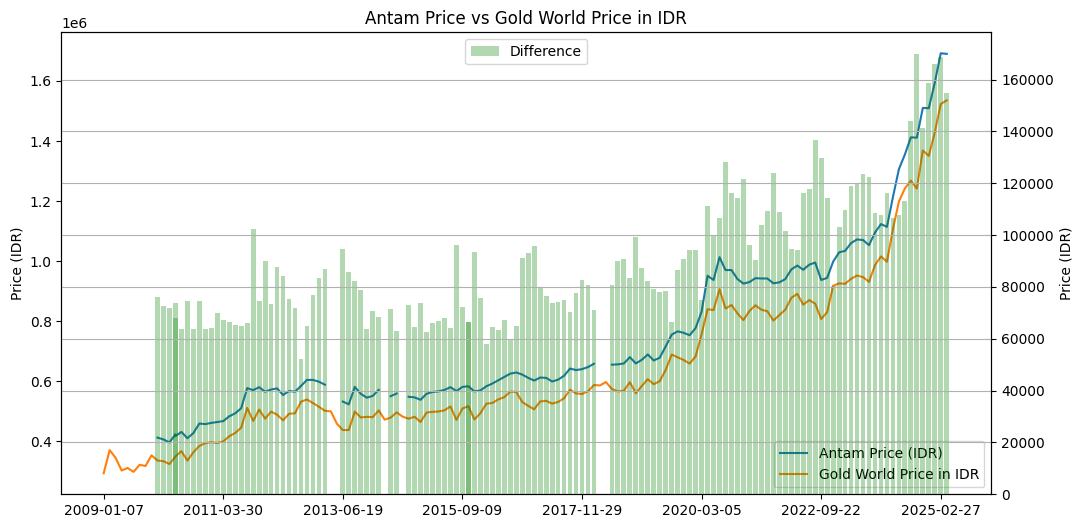

In [129]:
import matplotlib.pyplot as plt

# Display the 'antam' and 'gold_world_idr' columns
print(final_merged_df[['antam', 'gold_world_idr']].head())

# Plot the 'antam' and 'gold_world_idr' columns
plt.figure(figsize=(12, 6))

# Antam
plt.plot(final_merged_df['date'], final_merged_df['antam'], label='Antam Price (IDR)', zorder=2)
# Emas Global
plt.plot(final_merged_df['date'], final_merged_df['gold_world_idr'], label='Gold World Price in IDR', zorder=1)
plt.ylabel('Price (IDR)')
plt.legend(loc='lower right')


# # Kurs USD to IDR
# plt.twinx().plot(final_merged_df['date'], final_merged_df['kurs'].str.replace(',', '').astype(float), label='Kurs USD to IDR', color='red')
# plt.ylabel('Kurs USD to IDR')

# Perbedaan Global dan Antam
ax2 = plt.twinx()
ax2.bar(final_merged_df['date'], final_merged_df['difference'], label='Difference', color='green', alpha=0.3, zorder=0)
ax2.set_ylabel('Difference')
ax2.legend(loc='upper left')

plt.xlabel('Year')
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.ylabel('Price (IDR)')
plt.title('Antam Price vs Gold World Price in IDR')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()